In [2]:
import torch 
import torch.nn as nn 
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms 
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 

Using Device cpu
Epoch 1/5 | Loss: 319.4120
Epoch 2/5 | Loss: 148.3217
Epoch 3/5 | Loss: 101.7854
Epoch 4/5 | Loss: 77.1382
Epoch 5/5 | Loss: 60.2507
Total Accuracy: 97.26%
Model Saved As minst_model.pth


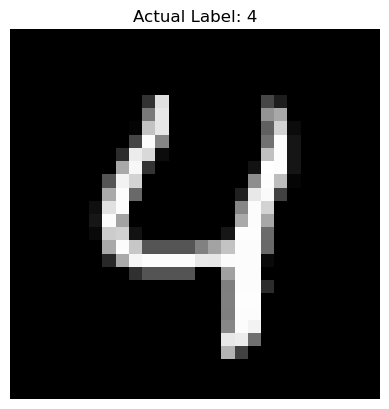

User Picked Image Index 4
Actual Label 4
Model Prediction 4


In [8]:
# MNIST PROJECT 

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using Device", device)

# Converts Images Into PyTorch Tensor
transform = transforms.ToTensor()

# Loading, Training And Testing Data:

train_data = MNIST(
    root="data",
    train=True, # Here it trains the data thats why true
    download=True,
    transform=transform
)

test_data= MNIST(
    root="data",
    train=False, # here it tests those 10,000 images thats why false 
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True # shuffles the photos 
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False # no need to shuffle photos in testing phase 
)

class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),

            nn.Linear(128,10)
        )

    def forward(self,x):
        return self.net(x)
model = DigitModel().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for image, labels in train_loader:
        image = image.view(image.size(0), -1).to(device)

        optimizer.zero_grad()
        outputs = model(image)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step() 

        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct/total
    print(f"Total Accuracy: {accuracy:.2f}%")

    torch.save(model.state_dict(), "minst_model.pth")
    print("Model Saved As minst_model.pth")

    index = 4
    image, true_label = test_data[index]

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Actual Label: {true_label}")
    plt.axis("off")
    plt.show()

    image_flat = image.view(1, -1).to(device)

    with torch.no_grad():
        output = model(image_flat)
        predicted_label = output.argmax(dim=1).item()

    print("User Picked Image Index", index)
    print("Actual Label", true_label)
    print("Model Prediction", predicted_label)
        